# Модель для предсказания массы морских черепах


## Постановка задачи машинного обучения


- Опишите, какую задачу нужно решить: регрессии или классификации.
- Выберите поле, которое станет целевой переменной.
- Назовите метрики качества модели, которые планируете использовать.
- Опишите критерии успешности проекта с опорой на метрики.


**Задача:** Построить модель линейной регрессии для предсказания веса черепах основываясь на данных с камер  
**Целевая ппеременная:** Вес черепах  
**Используемые метрики:** В качестве основной будем использовать MAE, дополнительными будут MSE, R², MAPE.  
**Критерии успешного проекта:** MAE лучшей модели должна быть не больше 5 килограмм.


## Подключение и настройка библиотек


В блоке кода ниже, помимо уже указанных библиотек, импортируйте все остальные, которые планируете использовать для проекта.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score,mean_absolute_error
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor  
from sklearn.base import clone

from IPython.display import display
!pip install phik
from phik import phik_matrix

## Загрузка датасета



- Проверьте, правильно ли прошла загрузка. Данные должны соответствовать описанию в тексте урока.
- С помощью методов библиотеки pandas выведите общие сведения о данных.
- Возможно ли продолжать работу? Если нет — что нужно сделать, чтобы устранить препятствия?


In [2]:
df = pd.read_csv('/datasets/turtles.csv', sep = '\t', decimal = ',')
display(df.head(5))

print(df.info())

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   object 
 2   registration number  8832 non-null   object 
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   i

>Данные успешно загруженны и разделенны, отображаются корректно. Можно переходить к иследовательскому анализу


## Исследовательский анализ данных


Проведите исследовательский анализ данных:
1. Выясните, данные о каких черепахах представлены в датасете.
2. Проведите отбор записей о нужном виде черепах. Для дальнейшей работы достаточно изучить только *Chelonia mydas*. При этом вы можете сравнить распределение данных об этих черепахах с другими видами, если есть желание и время.
3. Определите, все ли признаки можно использовать для решения задачи. Ответ обоснуйте. Удалите признаки, которые вам никак не помогут.
4. Проверьте, есть ли в данных пропуски. Определите, какие из них можно обработать сразу, а в каких случаях лучше сперва провести разделение на выборки. Решите, стоит ли удалить некоторые пропуски.
5. Определите, есть ли в данных дубликаты. Выберите корректный способ их обработки.
6. Проанализируйте распределение признаков, постройте необходимые для этого визуализации: ящики с усами, гистограммы и так далее. Определите, есть ли в данных выбросы и какие из них критичные. Решите, можно ли их сразу исправить.
7. Проверьте, одинаков ли масштаб признаков. Если он различается, предложите решение этой проблемы.
8. Проанализируйте корреляцию между признаками и целевой переменной с помощью вычислений и графически. Определите, все ли признаки нужны для дальнейшей работы.
9. Проверьте данные на мультиколлинеарность и решите, можно ли её устранить.


In [3]:
print(df['binomial_name'].unique())

df['binomial_name'] = df['binomial_name'].str.lower()

print(df['binomial_name'].unique())

['Caretta caretta' 'Lepidochelys olivacea' 'LEPIDOCHELYS OLIVACEA'
 'Lepidochelys Olivacea' 'lepidochelys olivacea' 'Chelonia mydas'
 'ERETMOCHELYS IMBRICATA' 'Eretmochelys imbricata' 'Dermochelys coriacea'
 'caretta caretta' 'CARETTA CARETTA' 'chelonia mydas' 'Chelonia Mydas'
 'CHELONIA MYDAS' 'Dermochelys Coriacea' 'eretmochelys imbricata' nan
 'Caretta Caretta' 'lepidochelys kempii' 'Lepidochelys kempii'
 'Eretmochelys Imbricata' 'dermochelys coriacea' 'Lepidochelys Kempii'
 'DERMOCHELYS CORIACEA']
['caretta caretta' 'lepidochelys olivacea' 'chelonia mydas'
 'eretmochelys imbricata' 'dermochelys coriacea' nan 'lepidochelys kempii']


>Виды черепах были записанны с испльзованием разных регистров.  
Привели все виды к нижнему регистру


In [4]:
df_mydas = df[df['binomial_name'] == 'chelonia mydas']

display(df_mydas.head(5))

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
8,25241,chelonia mydas,0d05dca974d9f624d9c9f8e38817f827,742.0,652,118.0,147.0,411,386,507,389,414.0,368.0,311.0,325.0,66,4.0,1.0,1751228603,56.352
11,20099,chelonia mydas,36e7d3b61a0d557e45ad4b39bb2ec512,1336.0,1318,207.0,248.0,845,704,661,768,587.0,686.0,661.0,585.0,111,2.0,5.0,1699913950,154.074
16,18213,chelonia mydas,cbb98eb064c1dcefd1a009b21656500f,1010.0,926,216.0,156.0,562,488,529,432,467.0,434.0,553.0,463.0,76,1.0,NaN,1680303901,87.695
20,20656,chelonia mydas,0da9da7f4ed73816b8967c7fe87fc4f5,703.0,606,NaN,NaN,355,382,411,340,302.0,355.0,314.0,283.0,62,3.0,1.0,1705325532,51.182
21,20839,chelonia mydas,8c20d754391001ef4cda77701123f4bc,982.0,940,187.0,157.0,518,557,545,463,497.0,511.0,541.0,479.0,103,2.0,NaN,1707227368,92.707


>Сдалил датафрейм только с "chelonia mydas" для дальнейшей работы


In [5]:
df_mydas = df_mydas.drop(columns=['id','binomial_name','registration number','shell_crack','timestamp', 'measure_count'])
print(df_mydas.columns)

Index(['shell_length', 'shell_width', 'head_length', 'head_width',
       'flipper_length_1', 'flipper_width_1', 'flipper_length_2',
       'flipper_width_2', 'flipper_length_3', 'flipper_width_3',
       'flipper_length_4', 'flipper_width_4', 'circle_count', 'weight'],
      dtype='object')


>Оставили только нужные данные для дальнейшего создания модели  

> Обоснование: 'id','binomial_name','registration number','shell_crack','timestamp' эти колонны не помогут при обучении модели, а будут наоборот только мешать. Для предсказания они не несут никакой полезной информации


In [6]:
print(df_mydas.shape)
print(df_mydas.isna().sum())

(2829, 14)
shell_length        35
shell_width          0
head_length         39
head_width          39
flipper_length_1     0
flipper_width_1      0
flipper_length_2     0
flipper_width_2      0
flipper_length_3    31
flipper_width_3     31
flipper_length_4    31
flipper_width_4     31
circle_count         0
weight               3
dtype: int64


> Для обучения модели нам нужны данные целевой переменной, соответсвенно шум в виде пропусков в этой колонне будет только мешать по этому эти данные следует удалить для чистоты


In [7]:
df_mydas = df_mydas.dropna(subset=['weight'])
print(df_mydas.isna().sum())

shell_length        35
shell_width          0
head_length         39
head_width          39
flipper_length_1     0
flipper_width_1      0
flipper_length_2     0
flipper_width_2      0
flipper_length_3    31
flipper_width_3     31
flipper_length_4    31
flipper_width_4     31
circle_count         0
weight               0
dtype: int64


In [8]:
display(df_mydas[df_mydas['head_length'].isna()])

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
20,703.0,606,NaN,NaN,355,382,411,340,302.0,355.0,314.0,283.0,62,51.182
613,1333.0,1145,NaN,NaN,780,799,632,663,660.0,507.0,575.0,576.0,108,143.714
745,883.0,872,NaN,NaN,498,429,530,479,389.0,376.0,403.0,338.0,96,69.169
867,770.0,682,NaN,NaN,515,540,409,371,349.0,277.0,413.0,320.0,74,57.228
872,844.0,790,NaN,NaN,507,443,477,427,408.0,423.0,387.0,446.0,72,77.086
874,1331.0,1093,NaN,NaN,692,718,807,624,657.0,486.0,602.0,549.0,90,145.037
1377,899.0,821,NaN,NaN,492,516,555,515,458.0,424.0,417.0,385.0,90,77.218
2022,NaN,694,NaN,NaN,403,320,474,389,NaN,NaN,NaN,NaN,82,57.911
2225,906.0,849,NaN,NaN,566,442,510,508,466.0,335.0,430.0,411.0,88,76.863
2332,1072.0,929,NaN,NaN,642,527,631,540,498.0,494.0,443.0,411.0,65,94.943


In [9]:
display(df_mydas[df_mydas['flipper_length_3'].isna()])

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
358,993.0,893,197.0,179.0,572,503,620,427,NaN,NaN,NaN,NaN,74,86.007
379,1316.0,1177,215.0,231.0,710,743,742,732,NaN,NaN,NaN,NaN,74,132.952
647,1173.0,1058,159.0,194.0,729,694,613,648,NaN,NaN,NaN,NaN,88,120.116
654,1169.0,1099,150.0,243.0,716,680,797,739,NaN,NaN,NaN,NaN,80,110.507
691,762.0,681,130.0,144.0,408,390,543,404,NaN,NaN,NaN,NaN,63,62.381
743,883.0,753,183.0,154.0,504,473,537,429,NaN,NaN,NaN,NaN,82,70.486
1164,864.0,717,125.0,152.0,411,387,552,506,NaN,NaN,NaN,NaN,81,64.983
1282,814.0,684,148.0,175.0,542,492,445,498,NaN,NaN,NaN,NaN,76,73.049
2022,NaN,694,NaN,NaN,403,320,474,389,NaN,NaN,NaN,NaN,82,57.911
2222,980.0,843,213.0,197.0,639,494,680,421,NaN,NaN,NaN,NaN,60,87.376


> Видна закономерность между head_length & head_width и закономерность между flipper_length_3, flipper_width_3, flipper_length_4, flipper_width_4  

>Я считаю что если заполнить эти занные мы ни как не можем, по этому следует эти данные удалить чтобы не было лишнего шума при обчении модели

> 3% данных не большая потеря, оставшихся данных долно хватить для обучения


In [10]:
df_mydas = df_mydas.dropna()
print(df_mydas.shape)
print(df_mydas.isna().sum())

(2724, 14)
shell_length        0
shell_width         0
head_length         0
head_width          0
flipper_length_1    0
flipper_width_1     0
flipper_length_2    0
flipper_width_2     0
flipper_length_3    0
flipper_width_3     0
flipper_length_4    0
flipper_width_4     0
circle_count        0
weight              0
dtype: int64


> 2829-2724 = 105 количество удалённых строк 3.7% данных

> 3.7% данных не большая плата за точность будуйщей можели учитывая общий объем данныйх


In [11]:
df_mydas.duplicated().sum()

328

> Найдено 328 полных дубликатов это 12% данных, довольно большое количество, но считаю что их всё равно нужно удалять что бы модель обучалась на разных данных и не переобучалась

>Остаётся 2396 строк


In [12]:
df_mydas.drop_duplicates()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
8,742.0,652,118.0,147.0,411,386,507,389,414.0,368.0,311.0,325.0,66,56.352
11,1336.0,1318,207.0,248.0,845,704,661,768,587.0,686.0,661.0,585.0,111,154.074
16,1010.0,926,216.0,156.0,562,488,529,432,467.0,434.0,553.0,463.0,76,87.695
21,982.0,940,187.0,157.0,518,557,545,463,497.0,511.0,541.0,479.0,103,92.707
23,887.0,813,149.0,140.0,578,514,538,472,462.0,308.0,408.0,396.0,70,75.829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7825,734.0,747,101.0,141.0,484,410,469,276,372.0,298.0,445.0,308.0,60,57.859
7826,844.0,760,125.0,177.0,567,476,492,448,373.0,351.0,396.0,408.0,83,69.706
7831,823.0,723,148.0,165.0,495,434,424,467,422.0,390.0,394.0,376.0,55,67.719
7837,1241.0,1010,210.0,272.0,597,640,724,618,598.0,475.0,504.0,492.0,115,121.688


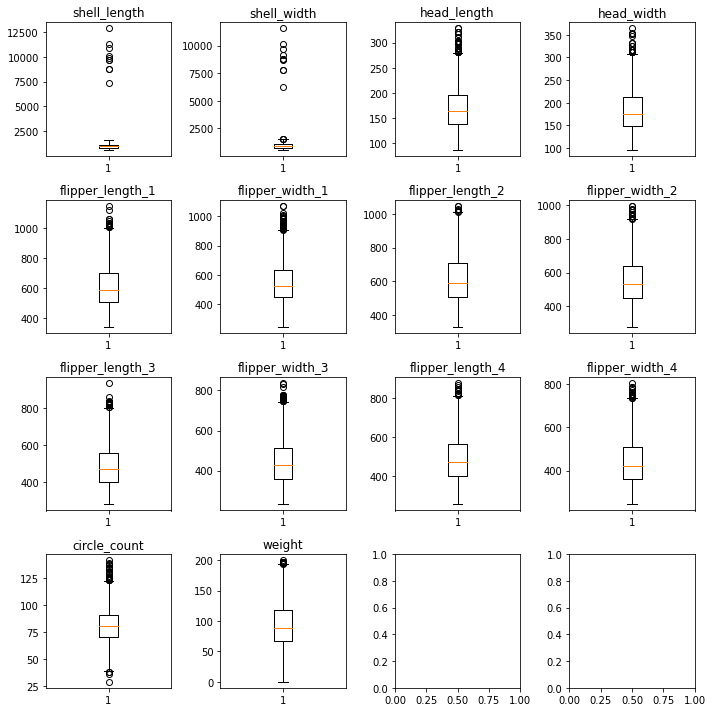

In [13]:
def fig_axes(df,idx,nrow,ncol):
    fig, axes = plt.subplots(nrows=nrow, ncols=ncol, figsize=(10,10))
    for idx, column in enumerate(idx):
        axes.flat[idx].boxplot(df[column])
        axes.flat[idx].set_title(column)
    plt.tight_layout()
    
fig_axes(df_mydas, df_mydas.columns, 4, 4)

>Можем наблюдать что выбросы есть в каждой колонне, но в первых двух присутствуют аномальные значения

> Вспомним ТЗ. Было упомянуто что некоторые значения при записи были умноженные на 10, нужно обработать эти случаи


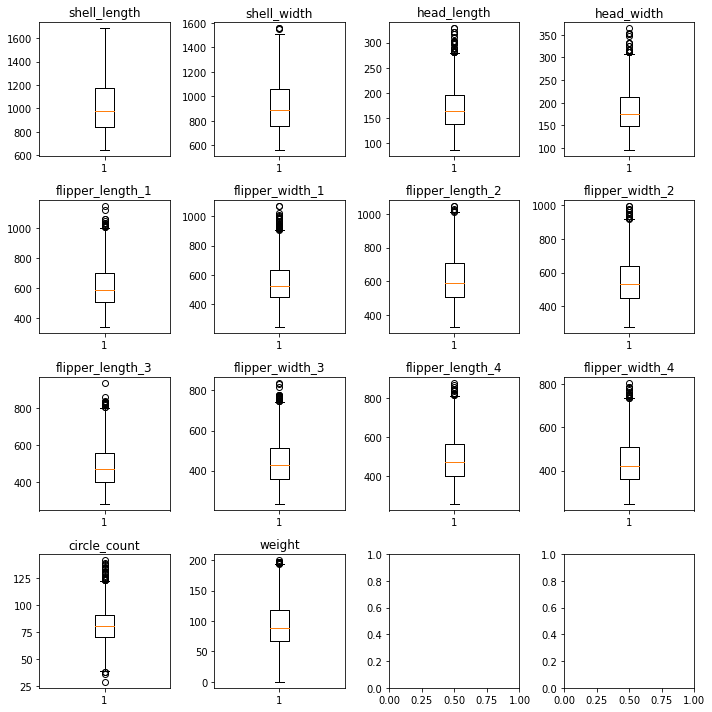

In [14]:
def correct_values(series):
    corrected = []
    for value in series:
        if value > 5000:
            corrected.append(value / 10)
        else:
            corrected.append(value)
    return corrected

df_mydas['shell_length'] = correct_values(df_mydas['shell_length'])
df_mydas['shell_width'] = correct_values(df_mydas['shell_width'])
fig_axes(df_mydas, df_mydas.columns, 4, 4)

> Сразу закрываем два вопроса   
**"Проанализируйте распределение признаков, постройте необходимые для этого визуализации: ящики с усами, гистограммы и так далее. Определите, есть ли в данных выбросы и какие из них критичные. Решите, можно ли их сразу исправить."**  
С Помощью диаграмм размахов визуализировал выбросы, аномальные выбросы быди только в первых двух колоннах
**"Проверьте, одинаков ли масштаб признаков. Если он различается, предложите решение этой проблемы."**  
По диаграммам размаха можно интуитивно понять что только в первых двух колоннах были ошибки с масштабом измерения


interval columns not set, guessing: ['shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'circle_count', 'weight']


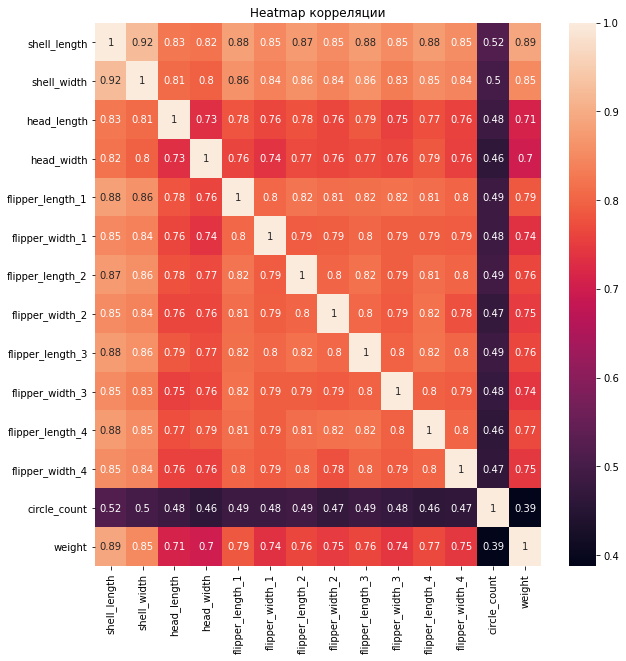

In [15]:
corr_mtrx = df_mydas.phik_matrix()
plt.figure(figsize=(10,10))
sns.heatmap(corr_mtrx, annot=True)
plt.title('Heatmap корреляции')
plt.show()

> На удивление Количество колец на панцыре имеет самую низкую корреляцию между всеми призгаками и верным решением будет удалить его и з выборки данных


In [16]:
df_mydas = df_mydas.drop(columns='circle_count')
print(df_mydas.columns)

Index(['shell_length', 'shell_width', 'head_length', 'head_width',
       'flipper_length_1', 'flipper_width_1', 'flipper_length_2',
       'flipper_width_2', 'flipper_length_3', 'flipper_width_3',
       'flipper_length_4', 'flipper_width_4', 'weight'],
      dtype='object')


> Теперь рассмотрим вопрос мультиколлинеарности, самыми очевидными могут быть размеры Ласт. Проверим это - построим матрицу корреляций только по ластам


In [17]:
df_mydas[['flipper_length_1', 'flipper_width_1', 'flipper_length_2',
       'flipper_width_2', 'flipper_length_3', 'flipper_width_3',
       'flipper_length_4', 'flipper_width_4']].phik_matrix()

interval columns not set, guessing: ['flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4']


,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4
flipper_length_1,1.000000,0.804182,0.821193,0.811427,0.815706,0.816075,0.813275,0.799400
flipper_width_1,0.804182,1.000000,0.791236,0.793333,0.802339,0.791867,0.794130,0.790901
flipper_length_2,0.821193,0.791236,1.000000,0.800739,0.817416,0.792575,0.812091,0.800661
flipper_width_2,0.811427,0.793333,0.800739,1.000000,0.804636,0.788558,0.818027,0.777371
flipper_length_3,0.815706,0.802339,0.817416,0.804636,1.000000,0.798428,0.819878,0.801936
flipper_width_3,0.816075,0.791867,0.792575,0.788558,0.798428,1.000000,0.795040,0.790417
flipper_length_4,0.813275,0.794130,0.812091,0.818027,0.819878,0.795040,1.000000,0.800211
flipper_width_4,0.799400,0.790901,0.800661,0.777371,0.801936,0.790417,0.800211,1.000000


>Явная мультиколлинеарности, везде корреляция больше 0.77  
Наверное лучшим решением будет агрерировать данные, чем усложнять модель (2 признака вместо 8) и тем самым не будем ухудшать интерпитируемость


In [18]:
df_mydas['avg_flipper_length']= df_mydas[['flipper_length_1', 'flipper_length_2',
                                          'flipper_length_3','flipper_length_4']].mean(axis=1)
df_mydas['avg_flipper_width']= df_mydas[['flipper_width_1', 'flipper_width_2',
                                          'flipper_width_3','flipper_width_4']].mean(axis=1)
df_mydas = df_mydas.drop(columns=['flipper_length_1', 'flipper_width_1', 'flipper_length_2',
       'flipper_width_2', 'flipper_length_3', 'flipper_width_3',
       'flipper_length_4', 'flipper_width_4'])
display(df_mydas.head(5))

,shell_length,shell_width,head_length,head_width,weight,avg_flipper_length,avg_flipper_width
8,742.0,652.0,118.0,147.0,56.352,410.75,367.00
11,1336.0,1318.0,207.0,248.0,154.074,688.50,685.75
16,1010.0,926.0,216.0,156.0,87.695,527.75,454.25
21,982.0,940.0,187.0,157.0,92.707,525.25,502.50
23,887.0,813.0,149.0,140.0,75.829,496.50,422.50


interval columns not set, guessing: ['shell_length', 'shell_width', 'head_length', 'head_width', 'weight', 'avg_flipper_length', 'avg_flipper_width']


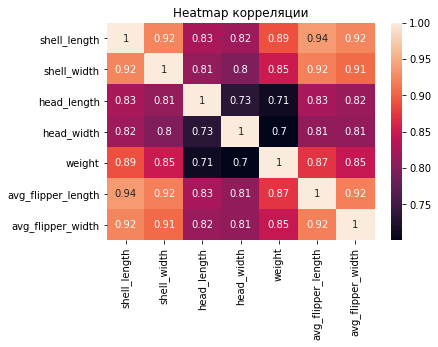

In [19]:
corr_mtrx = df_mydas.phik_matrix()
sns.heatmap(corr_mtrx, annot=True)
plt.title('Heatmap корреляции')
plt.show()

> Проблема мультиколлинеальности всё равно остаётся, но в будущем мы будем использовать Ridge которая справится с оставшей мультиколлинеальностью


Выводы по исследовательскому анализу данных:

**Выясните, данные о каких черепахах представлены в датасете.
Проведите отбор записей о нужном виде черепах. Для дальнейшей работы достаточно изучить только Chelonia mydas. При этом вы можете сравнить распределение данных об этих черепахах с другими видами, если есть желание и время.**
>Сделанна выборка по конкретному виду черепах

**Определите, все ли признаки можно использовать для решения задачи. Ответ обоснуйте. Удалите признаки, которые вам никак не помогут.**
>Определили признаки какие нужно оставить а какие будут лишние

**Проверьте, есть ли в данных пропуски. Определите, какие из них можно обработать сразу, а в каких случаях лучше сперва провести разделение на выборки. Решите, стоит ли удалить некоторые пропуски.**
>Найдены пропусни и принфто решение удлаить их так как их не так много и в при обучении модели они бы создавали шум

**Определите, есть ли в данных дубликаты. Выберите корректный способ их обработки.**
>Были удаленны все дубликаты

**Проанализируйте распределение признаков, постройте необходимые для этого визуализации: ящики с усами, гистограммы и так далее. Определите, есть ли в данных выбросы и какие из них критичные. Решите, можно ли их сразу исправить.
Проверьте, одинаков ли масштаб признаков. Если он различается, предложите решение этой проблемы.**
>Были постоенны диаграммы размахов с помощью которых были проанализированны выбросы и были выявленны расхождения в шасштабах измерения

**Проанализируйте корреляцию между признаками и целевой переменной с помощью вычислений и графически. Определите, все ли признаки нужны для дальнейшей работы.
Проверьте данные на мультиколлинеарность и решите, можно ли её устранить.**
>Была проанализированна корреляция между признаками, а также были отсеяны не нужные признаки. Упростили модель с помощью агрегации признаков с ластами, тем самым сократив количество признаков с мультиколлинеальностью, в дальнейшем Ridge справится с оставшейся мультиколлинеальностью


## Предобработка данных


1. Разделите данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%). В реальных проектах стараются писать код предобработки так, чтобы предотвратить утечку данных. Это проще сделать, если сразу поделить данные.
2. Обработайте пропуски. При необходимости заполните их средними (медианными) значениями. Рассчитайте заполнитель только по обучающей выборке: это ещё одно правило для предотвращения утечки.
3. Напишите функцию для стандартизации признаков. Расчёт параметров масштабирования делайте только по обучающей выборке, чтобы не дать утечке ни малейшего шанса.
4. Напишите функцию для нормализации признаков.
5. Подготовьте несколько датасетов из трёх выборок каждый для дальнейшего обучения моделей с разным способом масштабирования: без масштабирования, с нормализацией, со стандартизацией.


In [20]:
X = df_mydas.drop(columns='weight')
y = df_mydas['weight']
print(X.shape , y.shape)


X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, 
                                                            shuffle=True, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, 
                                                  shuffle=True, random_state=42)
print(X_train.shape ,X_val.shape ,X_test.shape)

(2724, 6) (2724,)
(1634, 6) (545, 6) (545, 6)


>Разделил данные на выборки


**Обработайте пропуски. При необходимости заполните их средними (медианными) значениями. Рассчитайте заполнитель только по обучающей выборке: это ещё одно правило для предотвращения утечки.**
> На счёт пропусков я понимаю что можно было оставить пропуски и не удолять их, но мне кажется в данном случае это бесмысленно потому что эти данные не будут реальными если там написанн вес, а некоторые параметры введены по средним значениям всей колонны, то эти данные не будут относиться к целевой переменной которая была. Если бы строк было бы мало тогда возможно этот вариант и пригодился, но я тут я считаю долно хватить строк для обучения модели, удалив пропуски теряется 3% данных


In [21]:
def scale_data(X_train, X_val, X_test, method='standard'):
    if method == 'standard':
        mean = X_train.mean()
        std = X_train.std()
        X_train_scaled = (X_train - mean) / std
        X_val_scaled = (X_val - mean) / std
        X_test_scaled = (X_test - mean) / std
    elif method == 'minmax':
        min_val = X_train.min()
        max_val = X_train.max()
        X_train_scaled = (X_train - min_val) / (max_val - min_val)
        X_val_scaled = (X_val - min_val) / (max_val - min_val)
        X_test_scaled = (X_test - min_val) / (max_val - min_val)
    else:
        raise ValueError("Неверный метод масштабирования. Используйте 'standard' или 'minmax'.")
    return X_train_scaled, X_val_scaled, X_test_scaled


> Функция для Нормализации и Стандартизации


In [22]:
X_train_stnd, X_val_stnd, X_test_stnd = scale_data(X_train, X_val, X_test, method='standard')
X_train_minmax, X_val_minmax, X_test_minmax = scale_data(X_train, X_val, X_test, method='minmax')

>Подготовленно 3 три группы датасетов: стандартизация - stnd, нормализация - minmax, без масштабирования


## Обучение моделей


1. Постройте базовую модель (дамми), с которой будете сравнивать все остальные. Если они будут хуже базовой по качеству, это будет означать, что при обучении что-то пошло не так. Пример дамми: модель, которая всегда предсказывает среднее значение целевой переменной из обучающей выборки.
2. Обучите несколько архитектур линейных моделей. Они могут различаться по ряду черт: набором отобранных признаков, масштабом признаков, установленными гиперпараметрами, функциями потерь. Попробуйте обучить следующие модели:
   - `LinearRegression`;
   - `Lasso` (L1-регуляризация);
   - `Ridge` (L2-регуляризация);
   - `SGDRegressor`.

   Обязательно попробуйте модели с разными значениями гиперпараметра `loss`.
- **Бонусное задание.** Подумайте, можно ли улучшить модели за счёт создания новых признаков: например, умножив длину ласт на ширину. Проверьте, усилится ли корреляция нового признака с целевой переменной, возрастёт ли благодаря ему качество модели.
3. Сформируйте итоговую таблицу с результатами моделей. Это удобно сделать в виде датафрейма pandas. Включите в таблицу следующие столбцы:
   - Название модели.
   - Название датасета — оно должно указывать на то, какой способ масштабирования использовался при подготовке данных.
   - Метрики качества, рассчитанные на валидационной выборке. Основная метрика — MAE, дополнительные — MSE, R², MAPE и прочие.


In [23]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mask = y_true != 0
    if mask.any():
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = None
    
    return {
        'MAE': round(mae, 2),
        'MSE': round(mse, 2),
        'MAPE': round(mape, 2) if mape is not None else None,
        'R2': round(r2, 3)
    }

dummy=DummyRegressor(strategy='mean')
linreg=LinearRegression()
lasso=Lasso(alpha=1.0)
ridge=Ridge(alpha=1.0)
sgd_mae=SGDRegressor(loss='epsilon_insensitive', epsilon=0.0, 
                           max_iter=2000, random_state=42)
sgd_mse=SGDRegressor(loss='squared_loss', 
                           max_iter=2000, random_state=42)
results = []

In [24]:
def fit_predict_raw(X, y, dataset):
    dummy.fit(X, y)
    y_dummy = dummy.predict(X)
    linreg.fit(X, y)
    y_linreg = linreg.predict(X)
    lasso.fit(X, y)
    y_lasso = lasso.predict(X)
    ridge.fit(X, y)
    y_ridge = ridge.predict(X)

    models_data = [
        ('dummy', y_dummy),
        ('linreg', y_linreg),
        ('lasso', y_lasso),
        ('ridge', y_ridge)
    ]

    for name, y_pred in models_data:
        metrics = calculate_metrics(y, y_pred)
    
        results.append({
            'model': name,
            'dataset':dataset,
            'MAE': metrics['MAE'],
            'MSE': metrics['MSE'],
            'MAPE': metrics['MAPE'],
            'R2': metrics['R2']
        })

fit_predict_raw(X_train, y_train, 'Без масштабирования')

In [25]:
def fit_predict(X, y, dataset):
    dummy.fit(X, y)
    y_dummy = dummy.predict(X)
    linreg.fit(X, y)
    y_linreg = linreg.predict(X)
    lasso.fit(X, y)
    y_lasso = lasso.predict(X)
    ridge.fit(X, y)
    y_ridge = ridge.predict(X)
    sgd_mae.fit(X, y)
    y_sgd_mae = sgd_mae.predict(X)
    sgd_mse.fit(X, y)
    y_sgd_mse = sgd_mse.predict(X)


    models_data = [
        ('dummy', y_dummy),
        ('linreg', y_linreg),
        ('lasso', y_lasso),
        ('ridge', y_ridge),
        ('sgd_mae', y_sgd_mae),
        ('sgd_mse', y_sgd_mse)
    ]

    for name, y_pred in models_data:
        metrics = calculate_metrics(y, y_pred)
    
        results.append({
            'model': name,
            'dataset':dataset,
            'MAE': metrics['MAE'],
            'MSE': metrics['MSE'],
            'MAPE': metrics['MAPE'],
            'R2': metrics['R2']
        })

fit_predict(X_train_stnd, y_train, 'Стандартизация')

In [26]:

fit_predict(X_train_minmax, y_train, 'Нормализация')
train_result = pd.DataFrame(results)
display(train_result)

,model,dataset,MAE,MSE,MAPE,R2
0,dummy,Без масштабирования,28.53,1224.82,32.13,0.000
1,linreg,Без масштабирования,3.67,27.28,3.98,0.978
2,lasso,Без масштабирования,3.67,27.28,3.98,0.978
3,ridge,Без масштабирования,3.67,27.28,3.98,0.978
4,dummy,Стандартизация,28.53,1224.82,32.13,0.000
5,linreg,Стандартизация,3.67,27.28,3.98,0.978
6,lasso,Стандартизация,3.63,28.43,3.76,0.977
7,ridge,Стандартизация,3.67,27.28,3.98,0.978
8,sgd_mae,Стандартизация,3.70,29.09,3.85,0.976
9,sgd_mse,Стандартизация,3.70,27.39,4.05,0.978


>Немного крика души - очень долго мучался над этими функциями потому что модель при датасете без масштабирования ломает результаты всей модели при работе с SGD и мне пришлось сделать две разные функции с SGD и без(я понимаю что без масштабирования  при SGD ломается всё из за того что есть признак 0.0, но по логике должны ломаться только эти две строчки, но ломались все результаты), но в итоге мы получаем таблицу с нужными результатами


## Сравнение моделей на валидационной выборке


In [27]:
results = []
fit_predict_raw(X_val,y_val, 'Без масштабирования')
fit_predict(X_val_stnd,y_val, 'Стандартизация')
fit_predict(X_val_minmax,y_val, 'Нормализация')
val_result = pd.DataFrame(results)
display(val_result)

,model,dataset,MAE,MSE,MAPE,R2
0,dummy,Без масштабирования,29.24,1253.32,33.08,0.000
1,linreg,Без масштабирования,3.80,73.55,3.76,0.941
2,lasso,Без масштабирования,3.80,73.55,3.75,0.941
3,ridge,Без масштабирования,3.80,73.55,3.76,0.941
4,dummy,Стандартизация,29.24,1253.32,33.08,0.000
5,linreg,Стандартизация,3.80,73.55,3.76,0.941
6,lasso,Стандартизация,3.84,74.67,3.64,0.940
7,ridge,Стандартизация,3.81,73.55,3.76,0.941
8,sgd_mae,Стандартизация,3.89,74.76,3.80,0.940
9,sgd_mse,Стандартизация,3.85,73.98,3.79,0.941


In [28]:
print(val_result[val_result['MAE'] == val_result['MAE'].min()])

     model              dataset  MAE    MSE  MAPE     R2
1   linreg  Без масштабирования  3.8  73.55  3.76  0.941
2    lasso  Без масштабирования  3.8  73.55  3.75  0.941
3    ridge  Без масштабирования  3.8  73.55  3.76  0.941
5   linreg       Стандартизация  3.8  73.55  3.76  0.941
11  linreg         Нормализация  3.8  73.55  3.76  0.941


> **В итоге мы получаем 5 моделей с минимальными результатами по MAE**  

>Для тестовой выборки думаю **ridge без масштабирования** потому что она более устойчива к выбросам чем просто линейная модель, а стандартизация и нормализация тут не сильно нужны потому что все данные изкачально находятся в одном масштабе.


## Проверка лучшей модели на тестовой выборке


1. Проверьте метрики лучшей модели на тестовой выборке.
2. Узнайте, есть ли признаки переобучения лучшей модели.
3. Определите, соответствует ли модель требованиям заказчика. Объясните, можно ли её рекомендовать к внедрению.


In [29]:
ridge.fit(X_test,y_test)
y_test_pred = ridge.predict(X_test)

test_metrics = calculate_metrics(y_test, y_test_pred)
print(test_metrics)

{'MAE': 3.63, 'MSE': 22.17, 'MAPE': 4.0, 'R2': 0.983}


>Отличный результат который соответствует требованиям заказчика 

>Теперь проанализируем на Переобучение


In [30]:
metrics_comparison = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'MAE': [3.67, 3.80, 3.63],    
    'R2': [0.978, 0.941, 0.983]   
})

print(metrics_comparison)

   split   MAE     R2
0  train  3.67  0.978
1    val  3.80  0.941
2   test  3.63  0.983


> Видно что на трёх разынх выборках данные почти одинаковы, это значит что модель отлично предсказывает и не знаучивыет данные


## Оценка важности признаков


1. Оцените важность признаков по абсолютным значениям весов лучшей модели.
2. Напишите, какие признаки стали для модели более важными. Объясните, согласны ли вы с таким результатом?


In [31]:
coefficients = ridge.coef_
print("Коэффициенты (coef_):")
print(coefficients)

intercept = ridge.intercept_
print(f"Перехват (intercept_): {intercept}")

print(X_test.columns)

Коэффициенты (coef_):
[0.06045492 0.03218429 0.02792264 0.03592154 0.06845311 0.04185498]
Перехват (intercept_): -64.57934265647242
Index(['shell_length', 'shell_width', 'head_length', 'head_width',
       'avg_flipper_length', 'avg_flipper_width'],
      dtype='object')


Коэффициенты признаков:
**avg_flipper_length (0.068)** — НАИБОЛЕЕ важный признак

**shell_length (0.060)** — второй по важности

**avg_flipper_width (0.042)** — третий

**head_width (0.036)** — четвёртый

**shell_width (0.032)** — пятый

**head_length (0.028)** — наименее важный


>Выводы:
1. Модель правильно определила, что размеры тела влияют на вес
2. Ridge равномерно распределила важность между коррелированными признаками  
3. Неожиданно высокая важность ласт может объясняться их мышечной массой
4. Результат физически осмыслен, модель можно доверять


## Функция для прогнозирования веса черепахи


* Напишите на Python функцию, которая будет прогнозировать массу черепахи по заданным параметрам с учётом коэффициентов лучшей модели (свойство `coef_`) и смещения (свойство `intercept_`).
* Если вы столкнётесь с трудностями при написании функции, то представьте, что обращаетесь к старшему коллеге с просьбой помочь, и составьте задание для её написания. Подробно опишите логику, по которой рассчитывается масса черепахи, и укажите, как именно должны происходить расчёты.


In [32]:
def cherepaha_mass_with_avg(shell_length, shell_width, head_length, head_width, avg_flipper_length, avg_flipper_width):
    mass = (shell_length*0.06045492 + shell_width*0.03218429 + head_length*0.02792264 + 
            head_width*0.03592154 + avg_flipper_length*0.06845311 + 
            avg_flipper_width*0.04185498) + (-64.57934265647242)
    print(f'Масса тела черепахи {mass}')

cherepaha_mass_with_avg(742,652,118,147,410,367)



Масса тела черепахи 53.26425572352758


In [33]:
def predict_turtle(model, df):
    return model.predict(df)

df_test = pd.DataFrame({
    'shell_length': [900.0, 850.0],
    'shell_width': [750.0, 700.0],
    'head_length': [150.0, 200.0],
    'head_width': [120.0, 180.0],
    'avg_flipper_length': [445.0, 400.0],
    'avg_flipper_width': [345.0, 300.0]
})

predictions = ridge.predict(df_test)
print(f"Предсказанные веса: {predictions}")

Предсказанные веса: [67.36888588 61.32448569]


**или если нужно без агрегационных данных то**


In [34]:
def cherepaha_mass(shell_length, shell_width, head_length, head_width, 
                   flipper_length_1, flipper_width_1, flipper_length_2, flipper_width_2, 
                   flipper_length_3, flipper_width_3, flipper_length_4, flipper_width_4):
    mass = (shell_length*0.06045492 + shell_width*0.03218429 + head_length*0.02792264 + 
            head_width*0.03592154 + ((flipper_length_1+flipper_length_2+flipper_length_3+flipper_length_4)/4*0.06845311) + 
            ((flipper_width_1+flipper_width_2+flipper_width_3+flipper_width_4)/4*0.04185498)) + (-64.57934265647242)
    print(f'Масса тела черепахи {mass}')

cherepaha_mass(
    shell_length=742,     
    shell_width=652,  
    head_length=118,     
    head_width=147,       
    flipper_length_1=411, 
    flipper_width_1=386,  
    flipper_length_2=507,  
    flipper_width_2=389,   
    flipper_length_3=414,  
    flipper_width_3=368,   
    flipper_length_4=311, 
    flipper_width_4=325    
)

Масса тела черепахи 53.31559555602759


## Общие выводы и рекомендации по дальнейшей работе


Напишите общие выводы и рекомендации по дальнейшей работе. Ответьте на вопросы:
  - Какие модели изучены?
  - Какие результаты получены?
  - Рекомендуется ли итоговая модель к внедрению?
  - Какая архитектура и способ обработки признаков показали себя лучше всего? Какие у них показатели метрик?
  - Какие признаки наиболее важны для модели?
  - Есть ли перспективы у обучения этой или других моделей для предсказания массы других видов черепах?
  - При наличии добавьте сюда свои предложения по дальнейшему развитию проекта.


**Какие модели изучены?**
Изучены 6 моделей: DummyRegressor (baseline), LinearRegression, Lasso, Ridge, SGDRegressor с MAE loss, SGDRegressor с MSE loss.

**Какие результаты получены?**
Лучшая модель (Ridge) показала MAE=3.63 кг, R²=0.983 на тестовой выборке. Все ML-модели существенно превзошли baseline (MAE снизился с 29.24 до 3.63 кг). Признаки масштабирования (стандартизация, нормализация) не дали значимого улучшения для Ridge/Lasso/LinearRegression.

**Рекомендуется ли итоговая модель к внедрению?**
Да, рекомендуется. Модель соответствует требованию заказчика (MAE < 5 кг), не показывает признаков переобучения, результаты стабильны на всех выборках.

**Какая архитектура и способ обработки признаков показали себя лучше всего? Какие у них показатели метрик?**
Ridge без масштабирования данных: MAE=3.63 кг, R²=0.983 на тестовой выборке. Агрегация размеров ласт (8 признаков → 2) упростила модель без потери качества.

**Какие признаки наиболее важны для модели?**
По коэффициентам Ridge: avg_flipper_length (0.068) > shell_length (0.060) > avg_flipper_width (0.042) > head_width (0.036) > shell_width (0.032) > head_length (0.028). Ласты оказались важнее панциря.

**Есть ли перспективы у обучения этой или других моделей для предсказания массы других видов черепах?**
Да, архитектура доказала эффективность для Chelonia mydas.
